# Build the eddy-centre stratification cache

This notebook calculates environmental buoyancy frequency and writes one row per existing eddy-day. It **does not calculate or modify tilt**. `xroms.density` supplies the ROMS equation of state, then $N^2=-g\rho_0^{-1}\partial\rho/\partial z$ is evaluated down each requested column; depth-weighted values are summarized over the upper 200 and 500 m.

The build is restartable and parallel by 30-day ROMS file. Within each file, all eddy centres required on a timestep are selected together and computed once. Completed files are stored under a cache-versioned partition folder and skipped on rerun.

Run this once on Katana before notebook 02. Inspect the model variable names and the sign/range checks before accepting the cache.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

HERE = Path.cwd()
ANALYSIS_ROOT = HERE.parent
if str(ANALYSIS_ROOT) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_ROOT))
if str(ANALYSIS_ROOT / "beta_effect_background_flow") not in sys.path:
    sys.path.insert(0, str(ANALYSIS_ROOT / "beta_effect_background_flow"))

import seacofs_tilt_tools as tilt
import mechanism_tools as mech

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df, _ = tilt.load_tilt_tables(paths)
df = mech.require_tilt_measurements(df)
print(f"Rows: {len(df):,}; measured tilts: {df.TiltDis.notna().sum():,}; eddies: {df.Eddy.nunique():,}")


Rows: 127,426; measured tilts: 105,621; eddies: 2,982


In [2]:
MODEL_ROOT = Path("/srv/scratch/z3533156/26year_BRAN2020")
N2_CACHE = Path("/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/tilt_mechanisms/n2_eddy_day_v3_core.parquet")
WORKERS = 7              # Start with 4-8; increase only after checking memory.
POINT_BATCH_SIZE = 128  # Vectorized eddy columns per backend read.

required_model_columns = ["Eddy", "Day", "ic", "jc", "xc", "yc", "Rc", "q11", "q12", "q22"]
df[required_model_columns].isna().mean().rename("missing_fraction")


Eddy    0.0
Day     0.0
ic      0.0
jc      0.0
xc      0.0
yc      0.0
Rc      0.0
q11     0.0
q12     0.0
q22     0.0
Name: missing_fraction, dtype: float64

In [3]:
# One process per model file; completed partitions are reused after interruption.
n2_cache = mech.build_n2_cache_xroms(
    df,
    MODEL_ROOT,
    N2_CACHE,
    depths=(200, 500),
    workers=WORKERS,
    point_batch_size=POINT_BATCH_SIZE,
    grid_path=paths.grid,
    z_r_path=paths.z_r,
    skip_existing=True,
)
n2_cache.head()


[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done   4 tasks      | elapsed:  1.4min
[Parallel(n_jobs=7)]: Done  11 tasks      | elapsed:  2.4min
[Parallel(n_jobs=7)]: Done  18 tasks      | elapsed:  3.3min
[Parallel(n_jobs=7)]: Done  27 tasks      | elapsed:  4.7min
[Parallel(n_jobs=7)]: Done  36 tasks      | elapsed:  5.8min
[Parallel(n_jobs=7)]: Done  47 tasks      | elapsed:  7.5min
[Parallel(n_jobs=7)]: Done  58 tasks      | elapsed:  8.8min
[Parallel(n_jobs=7)]: Done  71 tasks      | elapsed: 10.8min
[Parallel(n_jobs=7)]: Done  84 tasks      | elapsed: 12.8min
[Parallel(n_jobs=7)]: Done  99 tasks      | elapsed: 14.6min
[Parallel(n_jobs=7)]: Done 114 tasks      | elapsed: 16.9min
[Parallel(n_jobs=7)]: Done 131 tasks      | elapsed: 19.4min
[Parallel(n_jobs=7)]: Done 148 tasks      | elapsed: 22.1min
[Parallel(n_jobs=7)]: Done 167 tasks      | elapsed: 24.7min
[Parallel(n_jobs=7)]: Done 186 tasks      | elapsed: 27.3min
[Parallel(

,Eddy,Day,N2_core_cells,N2_200m_core_s2,N2_200m_core_std_s2,N2_200m_core_valid_cells,N2_200m_core_valid_fraction,N2_200m_centre_s2,N2_500m_core_s2,N2_500m_core_std_s2,N2_500m_core_valid_cells,N2_500m_core_valid_fraction,N2_500m_centre_s2
0,1,1462,74,0.000076,0.000005,74,1.0,0.000074,0.000063,0.000002,74,1.0,0.000063
1,1,1463,67,0.000081,0.000005,67,1.0,0.000085,0.000066,0.000002,67,1.0,0.000067
2,1,1464,81,0.000082,0.000003,81,1.0,0.000084,0.000066,0.000001,81,1.0,0.000067
3,1,1465,98,0.000079,0.000005,98,1.0,0.000084,0.000065,0.000002,98,1.0,0.000067
4,1,1466,109,0.000079,0.000004,109,1.0,0.000084,0.000065,0.000001,109,1.0,0.000067


,N2_200m_core_s2,N2_500m_core_s2,N2_200m_centre_s2,N2_500m_centre_s2
count,127426.000000,127426.000000,127424.000000,127424.000000
mean,0.000086,0.000076,0.000085,0.000075
std,0.000033,0.000016,0.000034,0.000016
min,0.000040,0.000045,0.000038,0.000038
1%,0.000042,0.000050,0.000041,0.000049
5%,0.000043,0.000054,0.000042,0.000053
50%,0.000081,0.000074,0.000080,0.000073
95%,0.000146,0.000102,0.000148,0.000101
99%,0.000173,0.000116,0.000176,0.000113
max,0.000324,0.000323,0.000336,0.000336


N2_200m_core_s2 positive fraction: 1.0 missing: 0.0
N2_500m_core_s2 positive fraction: 1.0 missing: 0.0


,N2_core_cells,N2_200m_core_valid_fraction,N2_500m_core_valid_fraction
count,127426.000000,127426.0,127426.0
mean,605.851467,1.0,1.0
std,615.896149,0.0,0.0
min,11.000000,1.0,1.0
25%,209.000000,1.0,1.0
50%,394.000000,1.0,1.0
75%,778.000000,1.0,1.0
max,7331.000000,1.0,1.0


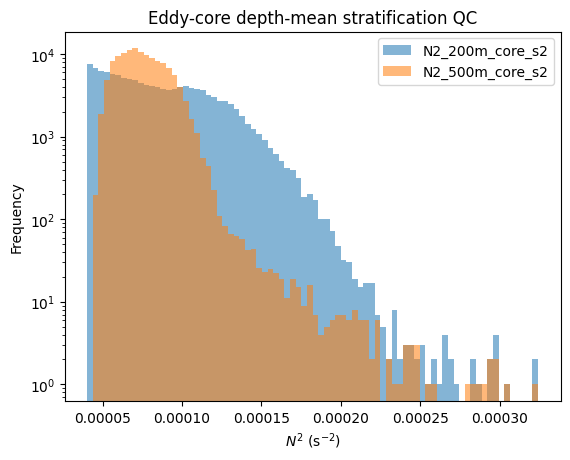

In [4]:
core_cols = ["N2_200m_core_s2", "N2_500m_core_s2"]
centre_cols = ["N2_200m_centre_s2", "N2_500m_centre_s2"]
display(n2_cache[core_cols + centre_cols].describe(percentiles=[.01, .05, .5, .95, .99]))
assert not n2_cache.duplicated(["Eddy", "Day"]).any()
for col in core_cols:
    print(col, "positive fraction:", (n2_cache[col] > 0).mean(), "missing:", n2_cache[col].isna().mean())
    if (n2_cache[col] > 0).mean() < 0.8:
        raise ValueError(f"{col} failed sign QC; check vertical-coordinate alignment.")

display(n2_cache[["N2_core_cells", "N2_200m_core_valid_fraction", "N2_500m_core_valid_fraction"]].describe())
n2_cache[core_cols].plot.hist(bins=80, logy=True, alpha=.55)
plt.xlabel(r"$N^2$ (s$^{-2}$)")
plt.title("Eddy-core depth-mean stratification QC")
plt.show()


## Acceptance checks

- Confirm `temp`, `salt`, ROMS vertical coordinates, `ic → xi_rho`, and `jc → eta_rho` on several manually selected profiles.
- Investigate negative or extreme values rather than silently clipping them. The depth means retain resolved negative values.
- Compare several cached columns against direct plots of `N2(z)`.
- Record the installed `xroms` version with the final results.


In [5]:
import xroms
print("xroms", xroms.__version__)
print("cache", N2_CACHE)


xroms 0.6.2
cache /srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/tilt_mechanisms/n2_eddy_day_v3_core.parquet
